# Q-INTERVAL-Lite+ — Sprint 3 Classification Model (EfficientNetV2-S + CBAM)

**Author:** Pasindu Pahasara · 104348348
**Project:** COS40005 Computing Technology Project A — Sprint 3 (Alpha Release)

This notebook replaces the Sprint 2 ResNet-50 model with **EfficientNetV2-S enhanced with a CBAM (Convolutional Block Attention Module)** attention mechanism, following supervisor guidance to adopt the higher-accuracy architectures reported in the mammography literature (e.g. EfficientNetV2 + CBAM, which has been reported to reach 99% accuracy on DDSM and INbreast).

The proven pipeline components from Sprint 2 are retained:
- Reproducibility seeds
- Stratified patient-level data split (maximum-severity rule)
- Mammo-Bench-specific normalisation at 384×384 resolution
- Albumentations augmentation (CLAHE, ShiftScaleRotate, brightness/contrast, CoarseDropout)
- Class-weighted cross-entropy loss
- Progressive unfreezing with discriminative learning rates
- Mixed precision training, cosine warm restarts, early stopping on Malignant recall
- Temperature scaling for probability calibration
- Grad-CAM++ visual explainability

**Note on evaluation honesty:** the 99% figures in the literature are typically reported on smaller datasets (DDSM, INbreast), often for binary classification and sometimes with image-level rather than patient-level splitting. This notebook evaluates on Mammo-Bench using a 3-class, patient-level protocol, which is more rigorous. The accuracy should be interpreted in that context.

## 0. Environment setup

Run once, then restart the kernel.

In [4]:
!pip install albumentations opencv-python-headless grad-cam --quiet

'pip' is not recognized as an internal or external command,
operable program or batch file.


## 1. Imports and reproducibility

Deterministic seeds across all random sources ensure experiments are reproducible and comparable.

In [5]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seeds set to {SEED}. Reproducible mode: ON.")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Seeds set to 42. Reproducible mode: ON.
Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Load metadata

Load the Mammo-Bench metadata CSV and confirm the image paths resolve.

In [6]:
DATA_ROOT = "."
CSV_PATH = "metadata.csv"

df = pd.read_csv(CSV_PATH)

sample_path = df.iloc[0]["preprocessed_image_path"]
full_path = os.path.normpath(os.path.join(DATA_ROOT, sample_path))
print(f"Sample path: {full_path}")
print(f"Path exists: {os.path.exists(full_path)}")
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Sample path: Preprocessed_Dataset\inbreast\inbreast_0.jpg
Path exists: True

Dataset shape: (19731, 25)
Columns: ['source_dataset', 'preprocessed_image_path', 'classification', 'density', 'BIRADS', 'mask_path', 'raw_image_path', 'laterality', 'view', 'source_subjectID', 'original_source_path', 'subject_age', 'abnormality', 'molecular_subtype', 'ROI_path', 'x', 'y', 'radius', 'abnormality id', 'calc type', 'calc distribution', 'subtlety', 'mass shape', 'mass margins', 'cropped_image_file_new']


## 3. Label mapping

Map the four raw labels to three classes (Suspicious Malignant -> Malignant) and assign numeric indices.

In [7]:
def map_label(label):
    if label == "Normal":
        return "Normal"
    elif label == "Benign":
        return "Benign"
    elif label in ["Malignant", "Suspicious Malignant"]:
        return "Malignant"
    else:
        raise ValueError(f"Unexpected label: {label!r}")

df["final_label"] = df["classification"].apply(map_label)

label_map = {"Normal": 0, "Benign": 1, "Malignant": 2}
reverse_map = {0: "Normal", 1: "Benign", 2: "Malignant"}
df["label_id"] = df["final_label"].map(label_map)

print("Class distribution:")
print(df["final_label"].value_counts())

Class distribution:
final_label
Malignant    8419
Benign       6069
Normal       5243
Name: count, dtype: int64


## 4. Data integrity check

Verify the multi-label patient rate and confirm subject IDs are globally unique (no cross-dataset collisions).

In [8]:
subject_label_counts = df.groupby('source_subjectID')['final_label'].nunique()
multi_label = subject_label_counts[subject_label_counts > 1]
print(f"Total subjects:                 {len(subject_label_counts)}")
print(f"Subjects with multiple labels:  {len(multi_label)} "
      f"({100*len(multi_label)/len(subject_label_counts):.2f}%)")

collisions = df.groupby('source_subjectID')['source_dataset'].nunique()
print(f"Cross-dataset ID collisions:    {(collisions > 1).sum()}")

Total subjects:                 5860
Subjects with multiple labels:  535 (9.13%)
Cross-dataset ID collisions:    0


## 5. Build final dataframe

Construct full image paths, verify they exist, and keep only the needed columns.

In [9]:
df["full_image_path"] = df["preprocessed_image_path"].apply(
    lambda x: os.path.join(DATA_ROOT, x)
)
missing = df[~df["full_image_path"].apply(os.path.exists)]
print(f"Missing image files: {len(missing)}")

columns_needed = ["full_image_path", "final_label", "label_id",
                  "source_subjectID", "density", "BIRADS"]
df = df[columns_needed].copy()
print(f"Final dataframe shape: {df.shape}")
df.head()

Missing image files: 0
Final dataframe shape: (19731, 6)


,full_image_path,final_label,label_id,source_subjectID,density,BIRADS
0,.\Preprocessed_Dataset/inbreast/inbreast_0.jpg,Normal,0,22678622,D,1.0
1,.\Preprocessed_Dataset/inbreast/inbreast_1.jpg,Benign,1,22678646,D,3.0
2,.\Preprocessed_Dataset/inbreast/inbreast_2.jpg,Normal,0,22678670,D,1.0
3,.\Preprocessed_Dataset/inbreast/inbreast_3.jpg,Benign,1,22678694,D,3.0
4,.\Preprocessed_Dataset/inbreast/inbreast_4.jpg,Malignant,2,22614074,B,5.0


## 6. Stratified group split (70 / 15 / 15)

Patient-aware and class-stratified split using a maximum-severity rule. Each patient is assigned the highest-severity label they have (Malignant > Benign > Normal) for stratification, while training labels remain per-image.

In [10]:
from sklearn.model_selection import train_test_split

subject_col = 'source_subjectID'

subject_label_df = (
    df.groupby(subject_col)['label_id'].max()
      .reset_index().rename(columns={'label_id': 'subject_label'})
)
subjects = subject_label_df[subject_col].values
subject_labels = subject_label_df['subject_label'].values

train_subjects, temp_subjects, _, temp_labels = train_test_split(
    subjects, subject_labels, test_size=0.30, random_state=SEED, stratify=subject_labels)
val_subjects, test_subjects = train_test_split(
    temp_subjects, test_size=0.50, random_state=SEED, stratify=temp_labels)

train_df = df[df[subject_col].isin(train_subjects)].copy()
val_df   = df[df[subject_col].isin(val_subjects)].copy()
test_df  = df[df[subject_col].isin(test_subjects)].copy()

print(f"Train: {len(train_df)} images / {len(train_subjects)} subjects")
print(f"Val:   {len(val_df)} images / {len(val_subjects)} subjects")
print(f"Test:  {len(test_df)} images / {len(test_subjects)} subjects")

# Verify no patient overlap
print(f"\nOverlap (should be 0/0/0): "
      f"{len(set(train_subjects)&set(val_subjects))} / "
      f"{len(set(train_subjects)&set(test_subjects))} / "
      f"{len(set(val_subjects)&set(test_subjects))}")

Train: 13780 images / 4102 subjects
Val:   2935 images / 879 subjects
Test:  3016 images / 879 subjects

Overlap (should be 0/0/0): 0 / 0 / 0


## 7. Compute Mammo-Bench normalisation statistics

Compute the per-channel mean and standard deviation on the training set, replacing ImageNet defaults (mammograms are grayscale, not natural colour images).

In [11]:
from tqdm import tqdm

sums = np.zeros(3); sums_sq = np.zeros(3); count = 0
print(f"Computing mean/std over {len(train_df)} training images...")
for path in tqdm(train_df['full_image_path'].values, desc="Stats"):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    sums += img.mean(axis=(0, 1)); sums_sq += (img**2).mean(axis=(0, 1)); count += 1

MEAN = (sums / count).tolist()
STD = np.sqrt(sums_sq / count - (sums / count)**2).tolist()
print(f"\nMEAN: {MEAN}\nSTD:  {STD}")

Computing mean/std over 13780 training images...


Stats: 100%|██████████| 13780/13780 [21:39<00:00, 10.60it/s] 


MEAN: [0.20708730262325717, 0.20708730262325717, 0.20708730262325717]
STD:  [0.275669406583642, 0.275669406583642, 0.275669406583642]


## 8. Augmentation pipeline (Albumentations)

EfficientNetV2-S is designed for 384×384 input. The training transform applies CLAHE, geometric, and intensity augmentations; validation/test transforms only resize and normalise.

In [12]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

INPUT_SIZE = 384

train_transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
    A.CoarseDropout(max_holes=2, max_height=24, max_width=24, p=0.2),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
print("Transforms defined.")

Transforms defined.


## 9. PyTorch Dataset class

Reads images with OpenCV (required by Albumentations) and applies the transform pipeline.

In [13]:
from torch.utils.data import Dataset

class MammoBenchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = cv2.cvtColor(cv2.imread(row['full_image_path']), cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)['image']
        return image, row['label_id']

## 10. DataLoaders

Batch size of 12 fits 384×384 EfficientNetV2-S within a 6 GB VRAM budget with mixed precision. `num_workers=0` avoids the Windows + Jupyter multiprocessing issue.

In [14]:
from torch.utils.data import DataLoader

train_dataset = MammoBenchDataset(train_df, transform=train_transform)
val_dataset   = MammoBenchDataset(val_df,   transform=val_test_transform)
test_dataset  = MammoBenchDataset(test_df,  transform=val_test_transform)

BATCH_SIZE = 12
g = torch.Generator(); g.manual_seed(SEED)

def seed_worker(worker_id):
    s = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(s); random.seed(s)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True,
                          generator=g, worker_init_fn=seed_worker)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, labels: {labels.shape}")
print(f"Pixel range: [{images.min():.3f}, {images.max():.3f}]")

Batch shape: torch.Size([12, 3, 384, 384]), labels: torch.Size([12])
Pixel range: [-0.751, 2.876]


## 11. CBAM — Convolutional Block Attention Module

CBAM (Woo et al., ECCV 2018) is a lightweight attention module that refines feature maps along two dimensions:

1. **Channel attention** — learns *which feature channels* are important, using both average-pooled and max-pooled descriptors passed through a shared MLP.
2. **Spatial attention** — learns *which spatial regions* are important, using channel-wise pooling followed by a convolution.

The two attention maps are applied sequentially to the feature map. In mammography, CBAM helps the model focus on the lesion regions rather than surrounding tissue, which is the mechanism behind the improved accuracy reported in the literature.

In [15]:
class ChannelAttention(nn.Module):
    """Channel attention: which feature channels matter."""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        # Shared MLP applied to both pooled descriptors
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    """Spatial attention: which spatial regions matter."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)       # channel-wise average
        max_out, _ = torch.max(x, dim=1, keepdim=True)     # channel-wise max
        out = torch.cat([avg_out, max_out], dim=1)         # (B, 2, H, W)
        return self.sigmoid(self.conv(out))


class CBAM(nn.Module):
    """Sequential channel then spatial attention."""
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)   # apply channel attention
        x = x * self.sa(x)   # apply spatial attention
        return x

print("CBAM module defined.")

CBAM module defined.


## 12. EfficientNetV2-S + CBAM model

The model uses an ImageNet-pretrained EfficientNetV2-S backbone, inserts a CBAM block after the feature extractor to refine the final feature maps, then applies global average pooling and a regularised classifier head.

EfficientNetV2-S outputs 1280 feature channels. The classifier head matches the Sprint 2 design: `Dropout -> Linear(1280, 256) -> ReLU -> Dropout -> Linear(256, 3)`.

In [16]:
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from sklearn.utils.class_weight import compute_class_weight

class EfficientNetV2_CBAM(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        backbone = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)
        self.features = backbone.features              # convolutional feature extractor
        num_features = backbone.classifier[1].in_features   # 1280 for EfficientNetV2-S
        self.cbam = CBAM(num_features)                 # attention on final feature maps
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(num_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def build_model():
    m = EfficientNetV2_CBAM(num_classes=3)
    # Freeze the entire backbone initially; CBAM and head stay trainable.
    for p in m.features.parameters():
        p.requires_grad = False
    return m

# ----- Class weights -----
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]),
                                     y=train_df['label_id'].values)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights [Normal, Benign, Malignant]: {class_weights.tolist()}")

model = build_model().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

def count_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"Initial trainable parameters: {count_trainable(model):,}")

Class weights [Normal, Benign, Malignant]: [1.2598280906677246, 1.0795142650604248, 0.7813119888305664]
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to C:\Users\pasin/.cache\torch\hub\checkpoints\efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:05<00:00, 14.7MB/s]


Initial trainable parameters: 533,605


## 13. Progressive unfreezing helpers

EfficientNetV2-S stores its stages in `model.features` (indices 0–7, where 0 is the stem and 7 is the top conv). Unlike ResNet's named `layer3`/`layer4`, we unfreeze by feature-block index.

The schedule:
- **Phase 1:** CBAM + classifier head only
- **Phase 2:** also unfreeze the deepest blocks (`features[6]`, `features[7]`)
- **Phase 3:** also unfreeze the next blocks (`features[4]`, `features[5]`)

Discriminative learning rates apply a smaller rate to earlier (more generic) blocks.

In [17]:
def set_block_requires_grad(model, indices, requires_grad):
    """Unfreeze/freeze specific feature-block indices in model.features."""
    for i in indices:
        for p in model.features[i].parameters():
            p.requires_grad = requires_grad

def build_optimizer(model, head_lr=1e-3, deep_lr=None, mid_lr=None, weight_decay=1e-4):
    """AdamW with discriminative learning rates by parameter group."""
    groups = []
    # Head + CBAM always trainable at head_lr
    head_params = [p for p in model.classifier.parameters() if p.requires_grad]
    head_params += [p for p in model.cbam.parameters() if p.requires_grad]
    if head_params:
        groups.append({'params': head_params, 'lr': head_lr})
    # Deep blocks (6, 7)
    if deep_lr is not None:
        deep = [p for i in (6, 7) for p in model.features[i].parameters() if p.requires_grad]
        if deep:
            groups.append({'params': deep, 'lr': deep_lr})
    # Mid blocks (4, 5)
    if mid_lr is not None:
        mid = [p for i in (4, 5) for p in model.features[i].parameters() if p.requires_grad]
        if mid:
            groups.append({'params': mid, 'lr': mid_lr})
    return torch.optim.AdamW(groups, weight_decay=weight_decay)

print("Unfreezing helpers defined.")

Unfreezing helpers defined.


## 14. Training and validation functions (mixed precision)

`train_epoch` uses automatic mixed precision for speed. `validate_one_epoch` returns per-class recall so the Malignant recall can drive early stopping.

In [18]:
from torch.amp import autocast, GradScaler
from sklearn.metrics import recall_score

def train_epoch(model, dataloader, criterion, optimizer, device, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    loop = tqdm(dataloader, desc="Training", leave=False)
    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        _, pred = torch.max(outputs, 1)
        correct += (pred == labels).sum().item(); total += labels.size(0)
        loop.set_postfix(loss=loss.item())
    return running_loss / total, correct / total

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0; all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, pred = torch.max(outputs, 1)
            all_preds.extend(pred.cpu().numpy()); all_labels.extend(labels.cpu().numpy())
    all_preds = np.array(all_preds); all_labels = np.array(all_labels)
    epoch_loss = running_loss / len(all_labels)
    epoch_acc = (all_preds == all_labels).mean()
    rec = recall_score(all_labels, all_preds, average=None, labels=[0,1,2], zero_division=0)
    return epoch_loss, epoch_acc, rec[2], rec

## 15. Progressive unfreezing training

Three-phase schedule with discriminative learning rates, mixed precision, cosine warm restarts in Phase 3, and early stopping on validation Malignant recall (patience reset per phase).

In [19]:
from torch.optim.lr_scheduler import CosineAnnealingLR, CosineAnnealingWarmRestarts

PATIENCE = 10
train_losses, val_losses, train_accs, val_accs, val_mal_recalls = [], [], [], [], []
best_malignant_recall = 0.0
scaler = GradScaler('cuda')
CHECKPOINT_PATH = "best_effnetv2_cbam.pth"

def run_phase(name, num_epochs, model, optimizer, criterion, device, scaler,
              use_warm_restarts=False):
    global best_malignant_recall
    patience_counter = 0
    if use_warm_restarts:
        scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=8, T_mult=1, eta_min=1e-6)
    else:
        scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    print(f"\n{'='*70}\n{name}\nTrainable params: {count_trainable(model):,}\n{'='*70}")
    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
        vl_loss, vl_acc, mal_recall, recalls = validate_one_epoch(model, val_loader, criterion, device)
        scheduler.step()
        train_losses.append(tr_loss); val_losses.append(vl_loss)
        train_accs.append(tr_acc); val_accs.append(vl_acc); val_mal_recalls.append(mal_recall)
        print(f"[{name} {epoch+1:>2}/{num_epochs}] tr {tr_loss:.4f}/{tr_acc:.3f} | "
              f"val {vl_loss:.4f}/{vl_acc:.3f} | "
              f"recall N {recalls[0]:.3f} B {recalls[1]:.3f} M {recalls[2]:.3f} | "
              f"lr {scheduler.get_last_lr()[0]:.2e}")
        if mal_recall > best_malignant_recall:
            best_malignant_recall = mal_recall; patience_counter = 0
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print(f"  ↑ new best Malignant recall {mal_recall:.4f}. Saved.")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  ✗ early stopping ({PATIENCE} epochs no improvement).")
                return True
    return False

# Phase 1 — CBAM + head only
optimizer = build_optimizer(model, head_lr=1e-3)
stopped = run_phase("Phase 1: CBAM + head", 3, model, optimizer, criterion, device, scaler)

# Phase 2 — + deepest blocks (6, 7)
if not stopped:
    set_block_requires_grad(model, [6, 7], True)
    optimizer = build_optimizer(model, head_lr=1e-3, deep_lr=1e-4)
    stopped = run_phase("Phase 2: + blocks 6-7", 5, model, optimizer, criterion, device, scaler)

# Phase 3 — + mid blocks (4, 5), with warm restarts
if not stopped:
    set_block_requires_grad(model, [4, 5], True)
    optimizer = build_optimizer(model, head_lr=1e-3, deep_lr=1e-4, mid_lr=1e-5)
    stopped = run_phase("Phase 3: + blocks 4-5", 32, model, optimizer, criterion, device,
                        scaler, use_warm_restarts=True)

print(f"\nBest Malignant recall across all phases: {best_malignant_recall:.4f}")


Phase 1: CBAM + head
Trainable params: 533,605


[Phase 1: CBAM + head  1/3] tr 0.9629/0.515 | val 0.8407/0.594 | recall N 0.876 B 0.342 M 0.602 | lr 7.50e-04
  ↑ new best Malignant recall 0.6017. Saved.


[Phase 1: CBAM + head  2/3] tr 0.9000/0.545 | val 0.7963/0.599 | recall N 0.860 B 0.400 M 0.582 | lr 2.51e-04


[Phase 1: CBAM + head  3/3] tr 0.8892/0.558 | val 0.7962/0.599 | recall N 0.863 B 0.481 M 0.522 | lr 1.00e-06

Phase 2: + blocks 6-7
Trainable params: 15,425,677


[Phase 2: + blocks 6-7  1/5] tr 0.7978/0.595 | val 0.7250/0.642 | recall N 0.672 B 0.691 M 0.589 | lr 9.05e-04


...

[Phase 3: + blocks 4-5 18/32] tr 0.5351/0.748 | val 0.7300/0.687 | recall N 0.894 B 0.694 M 0.555 | lr 8.54e-04


[Phase 3: + blocks 4-5 19/32] tr 0.5187/0.761 | val 0.7325/0.719 | recall N 0.871 B 0.606 M 0.707 | lr 6.92e-04


[Phase 3: + blocks 4-5 20/32] tr 0.4886/0.776 | val 0.7054/0.702 | recall N 0.881 B 0.713 M 0.583 | lr 5.01e-04


[Phase 3: + blocks 4-5 21/32] tr 0.4616/0.787 | val 0.7323/0.711 | recall N 0.884 B 0.587 M 0.694 | lr 3.09e-04


[Phase 3: + blocks 4-5 22/32] tr 0.4297/0.805 | val 0.7453/0.712 | recall N 0.886 B 0.628 M 0.666 | lr 1.47e-04
  ✗ early stopping (10 epochs no improvement).

Best Malignant recall across all phases: 0.7138


## 16. Training curves

Plot loss, accuracy, and validation Malignant recall across all epochs.

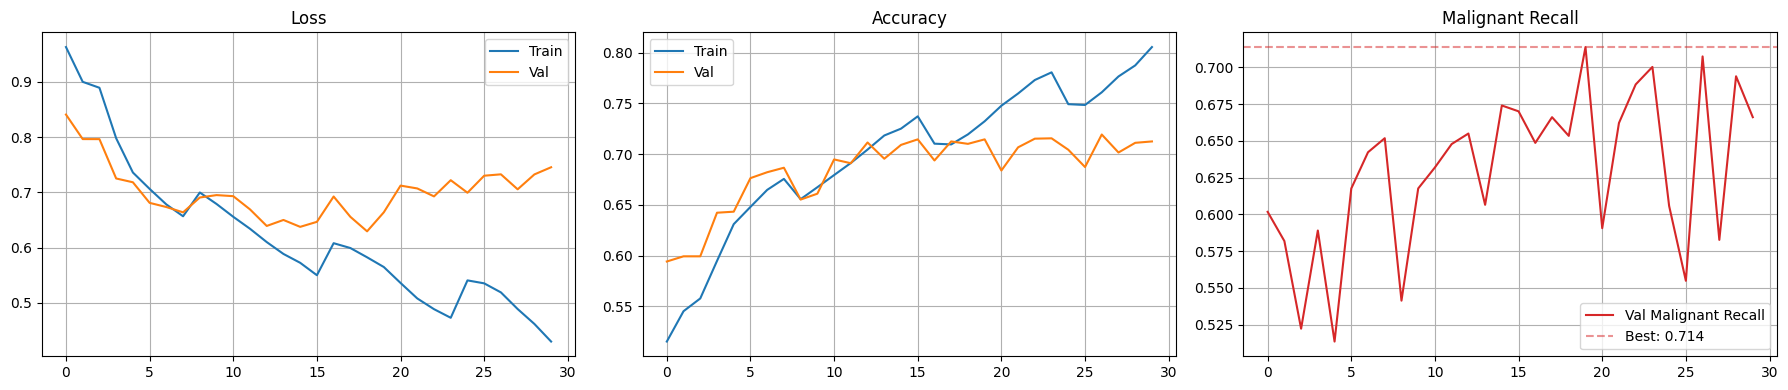

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(train_losses, label='Train'); axes[0].plot(val_losses, label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(train_accs, label='Train'); axes[1].plot(val_accs, label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)
axes[2].plot(val_mal_recalls, color='tab:red', label='Val Malignant Recall')
axes[2].axhline(best_malignant_recall, color='tab:red', ls='--', alpha=0.5,
                label=f'Best: {best_malignant_recall:.3f}')
axes[2].set_title('Malignant Recall'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()

## 17. Test set evaluation

Load the best checkpoint and evaluate on the held-out test set: accuracy, per-class metrics, macro F1, and confusion matrix.

Test Accuracy: 0.7129
Macro F1:      0.7105

              precision    recall  f1-score   support

      Normal       0.75      0.88      0.81       823
      Benign       0.61      0.58      0.59       911
   Malignant       0.76      0.70      0.73      1282

    accuracy                           0.71      3016
   macro avg       0.71      0.72      0.71      3016
weighted avg       0.71      0.71      0.71      3016



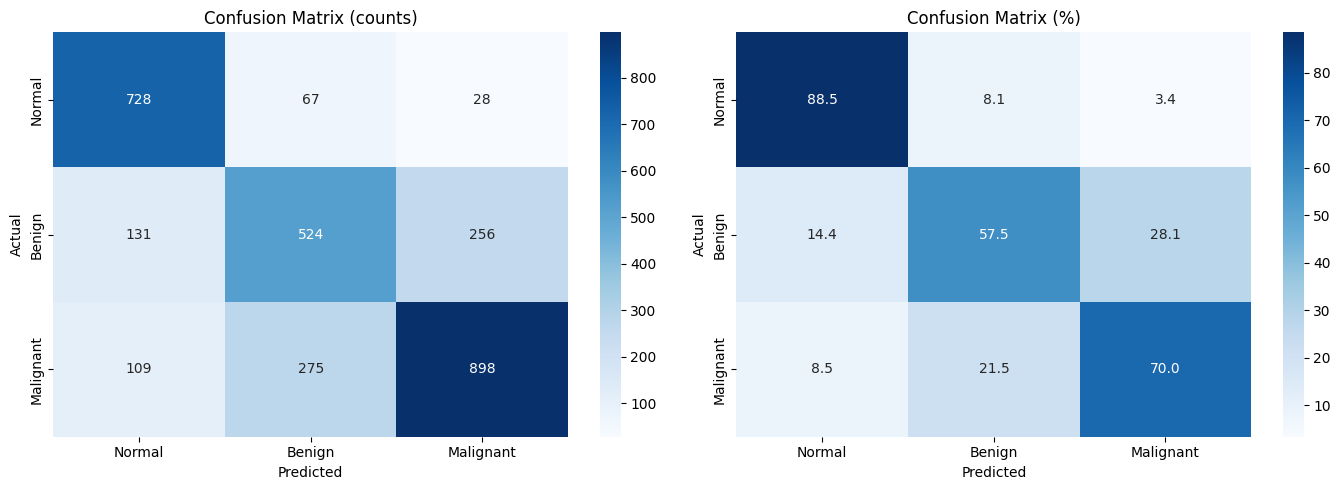

In [21]:
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report, roc_auc_score)
import seaborn as sns

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device); labels = labels.to(device)
        with autocast(device_type='cuda'):
            logits = model(images)
        probs = torch.softmax(logits, dim=1)
        _, pred = torch.max(logits, 1)
        all_preds.extend(pred.cpu().numpy()); all_labels.extend(labels.cpu().numpy())
        all_probs.append(probs.float().cpu().numpy())

y_true = np.array(all_labels); y_pred = np.array(all_preds)
y_probs = np.concatenate(all_probs)

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
print(f"Test Accuracy: {acc:.4f}")
print(f"Macro F1:      {macro_f1:.4f}\n")
print(classification_report(y_true, y_pred,
      target_names=['Normal','Benign','Malignant'], zero_division=0))

cm = confusion_matrix(y_true, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Normal','Benign','Malignant'],
            yticklabels=['Normal','Benign','Malignant'])
ax[0].set_title('Confusion Matrix (counts)'); ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual')
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax[1],
            xticklabels=['Normal','Benign','Malignant'],
            yticklabels=['Normal','Benign','Malignant'])
ax[1].set_title('Confusion Matrix (%)'); ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()

## 18. ROC-AUC and clinical metrics

One-vs-rest ROC-AUC per class, plus Malignant sensitivity and specificity.

In [22]:
y_onehot = np.eye(3)[y_true]
auc_per_class = roc_auc_score(y_onehot, y_probs, average=None, multi_class='ovr')
auc_macro = roc_auc_score(y_onehot, y_probs, average='macro', multi_class='ovr')
print("ROC-AUC per class:")
for i, n in enumerate(['Normal','Benign','Malignant']):
    print(f"  {n:<10s}: {auc_per_class[i]:.4f}")
print(f"Macro ROC-AUC: {auc_macro:.4f}")

mal_true = (y_true == 2).astype(int); mal_pred = (y_pred == 2).astype(int)
TP = ((mal_pred==1)&(mal_true==1)).sum(); TN = ((mal_pred==0)&(mal_true==0)).sum()
FP = ((mal_pred==1)&(mal_true==0)).sum(); FN = ((mal_pred==0)&(mal_true==1)).sum()
print(f"\nMalignant sensitivity: {TP/(TP+FN):.4f}")
print(f"Malignant specificity: {TN/(TN+FP):.4f}")

ROC-AUC per class:
  Normal    : 0.9643
  Benign    : 0.8127
  Malignant : 0.8553
Macro ROC-AUC: 0.8774

Malignant sensitivity: 0.7005
Malignant specificity: 0.8362


## 19. Temperature scaling (calibration)

Fit a single temperature scalar on the validation set to calibrate the probability outputs. Report ECE before and after.

In [23]:
# Collect validation logits
val_logits, val_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        with autocast(device_type='cuda'):
            logits = model(images)
        val_logits.append(logits.float().cpu()); val_labels.append(labels)
val_logits = torch.cat(val_logits); val_labels = torch.cat(val_labels)

temperature = nn.Parameter(torch.ones(1))
opt_T = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)
def _loss():
    opt_T.zero_grad()
    loss = nn.CrossEntropyLoss()(val_logits / temperature, val_labels)
    loss.backward(); return loss
opt_T.step(_loss)
T_opt = temperature.item()
print(f"Optimal temperature T = {T_opt:.4f}")

def ece(probs, labels, n_bins=15):
    conf = probs.max(axis=1); pred = probs.argmax(axis=1)
    acc = (pred == labels).astype(float); bins = np.linspace(0,1,n_bins+1); e = 0.0
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() > 0:
            e += m.sum()/len(probs) * abs(conf[m].mean() - acc[m].mean())
    return e

# Test logits
test_logits = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        with autocast(device_type='cuda'):
            test_logits.append(model(images).float().cpu())
test_logits = torch.cat(test_logits)
probs_uncal = torch.softmax(test_logits, dim=1).numpy()
probs_cal   = torch.softmax(test_logits / T_opt, dim=1).numpy()
print(f"ECE before: {ece(probs_uncal, y_true):.4f}")
print(f"ECE after:  {ece(probs_cal, y_true):.4f}")

Optimal temperature T = 1.1498
ECE before: 0.0777
ECE after:  0.0573


## 20. Grad-CAM++ visual explainability

Generate Grad-CAM++ heatmap overlays. For EfficientNetV2-S + CBAM, the target layer is the final feature block (`model.features[-1]`).

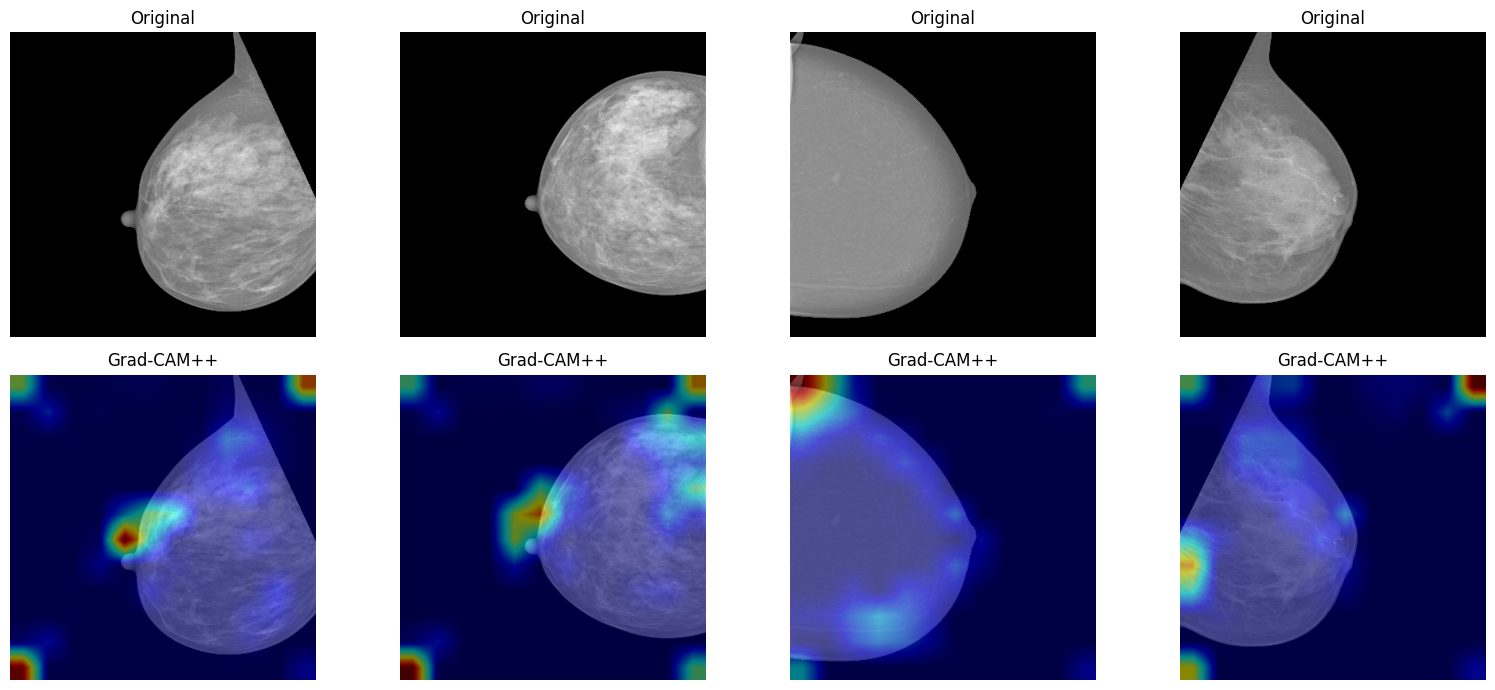

In [24]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layers = [model.features[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

def make_overlay(image_path, target_class=2):
    rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (INPUT_SIZE, INPUT_SIZE))
    norm = rgb.astype(np.float32) / 255.0
    tensor = val_test_transform(image=rgb)['image'].unsqueeze(0).to(device)
    grayscale = cam(input_tensor=tensor, targets=[ClassifierOutputTarget(target_class)])[0]
    return rgb, show_cam_on_image(norm, grayscale, use_rgb=True)

paths = test_df[test_df['label_id']==2]['full_image_path'].head(4).tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for c, p in enumerate(paths):
    img, ov = make_overlay(p, 2)
    axes[0,c].imshow(img); axes[0,c].set_title('Original'); axes[0,c].axis('off')
    axes[1,c].imshow(ov); axes[1,c].set_title('Grad-CAM++'); axes[1,c].axis('off')
plt.tight_layout(); plt.show()

## 21. Save final model bundle

Package the model weights, calibration temperature, normalisation statistics, input size, and class names into a single file for backend integration.

In [25]:
artefacts = {
    'model_state_dict': model.state_dict(),
    'architecture': 'EfficientNetV2-S + CBAM',
    'temperature': T_opt,
    'mean': MEAN, 'std': STD,
    'input_size': INPUT_SIZE,
    'class_names': ['Normal', 'Benign', 'Malignant'],
    'test_metrics': {
        'accuracy': float(acc),
        'macro_f1': float(macro_f1),
        'malignant_recall': float(recall_score(y_true, y_pred, average=None,
                                                labels=[0,1,2], zero_division=0)[2]),
        'macro_auc': float(auc_macro),
        'ece_before': float(ece(probs_uncal, y_true)),
        'ece_after': float(ece(probs_cal, y_true)),
    }
}
torch.save(artefacts, "final_effnetv2_cbam_bundle.pth")
print("Saved: final_effnetv2_cbam_bundle.pth")
for k, v in artefacts['test_metrics'].items():
    print(f"  {k:<20s}: {v:.4f}")

Saved: final_effnetv2_cbam_bundle.pth
  accuracy            : 0.7129
  macro_f1            : 0.7105
  malignant_recall    : 0.7005
  macro_auc           : 0.8774
  ece_before          : 0.0777
  ece_after           : 0.0573
